In [1]:
import pandas as pd 
import numpy as np

import matplotlib
matplotlib.use('TkAgg')

import matplotlib.pyplot as plt
from matplotlib import patches
from matplotlib import cm
from matplotlib.colors import ListedColormap
from matplotlib import animation
from mpl_toolkits.mplot3d.art3d import Line3DCollection

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Importing Data

In [2]:
data = np.load('data/data_molecule/molecule.npz')
positions = data['positions']
angles = data['angles']
distances = data['distances']
atomTypes = data['atomTypes']
edges = data['edges']

# Visualizing Molecule

In [12]:
%matplotlib widget

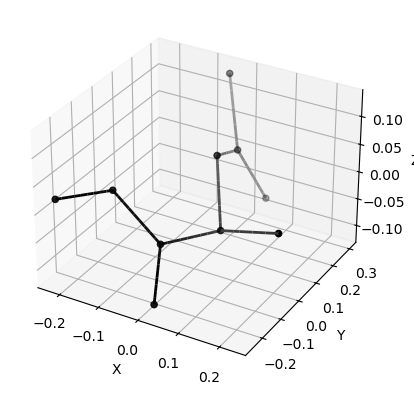

In [13]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
molecule = positions[0, :, :]

ax.scatter(molecule[:, 0], molecule[:, 1], molecule[:, 2], c="black", marker='o')

edge_depths = [(molecule[ai, 1] + molecule[bi, 1]) / 2 for ai, bi in edges]

min_depth = min(edge_depths)
max_depth = max(edge_depths)
normalize_depth = lambda d: 1 - (d - min_depth) / (max_depth - min_depth) / 2

for ai, bi in edges:
    xs = np.linspace(molecule[ai, 0], molecule[bi, 0], 10)
    ys = np.linspace(molecule[ai, 1], molecule[bi, 1], 10)
    zs = np.linspace(molecule[ai, 2], molecule[bi, 2], 10)
    
    segments = [
        [[xs[i], ys[i], zs[i]], [xs[i+1], ys[i+1], zs[i+1]]]
        for i in range(len(xs) - 1)
    ]
    
    normalized_ys = [normalize_depth(y) for y in ys[:-1]]
    colors = cm.Greys(normalized_ys)

    lc = Line3DCollection(segments, colors=colors, linewidths=2)
    ax.add_collection3d(lc)


ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()

In [14]:
%matplotlib inline
plt.clf()

# Animating Molecule

In [15]:
%matplotlib widget

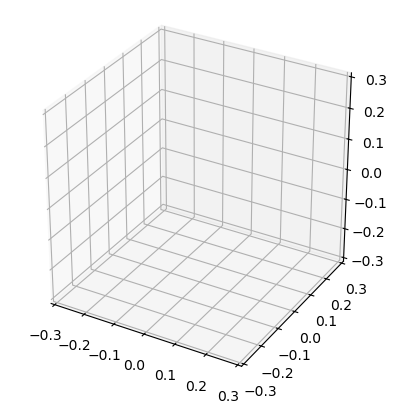

In [15]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
bounds = (-0.3, 0.3)
ax.set_xlim(*bounds)
ax.set_ylim(*bounds)
ax.set_zlim(*bounds)
ax.set_box_aspect([1, 1, 1])

atom_scatter = ax.scatter([], [], [], c='black')
bond_collections = []

def init():
    global bond_collections
    atom_scatter._offsets3d = ([], [], [])
    for coll in bond_collections:
        coll.remove()
    bond_collections = []
    return [atom_scatter]

def animate(i):
    global bond_collections
    molecule = positions[i, :, :]
    atom_scatter._offsets3d = (molecule[:, 0], molecule[:, 1], molecule[:, 2])

    for coll in bond_collections:
        coll.remove()
    bond_collections = []

    edge_depths = [(molecule[ai, 1] + molecule[bi, 1]) / 2 for ai, bi in edges]
    min_depth = min(edge_depths)
    max_depth = max(edge_depths)
    normalize_depth = lambda d: 1 - (d - min_depth) / (max_depth - min_depth + 1e-8) / 2

    for ai, bi in edges:
        xs = np.linspace(molecule[ai, 0], molecule[bi, 0], 10)
        ys = np.linspace(molecule[ai, 1], molecule[bi, 1], 10)
        zs = np.linspace(molecule[ai, 2], molecule[bi, 2], 10)

        segments = [
            [[xs[j], ys[j], zs[j]], [xs[j+1], ys[j+1], zs[j+1]]]
            for j in range(len(xs) - 1)
        ]

        normalized_ys = [normalize_depth(y) for y in ys[:-1]]
        colors = cm.Greys(normalized_ys)

        lc = Line3DCollection(segments, colors=colors, linewidths=2)
        ax.add_collection3d(lc)
        bond_collections.append(lc)

    return [atom_scatter] + bond_collections

ani = animation.FuncAnimation(fig, animate, init_func=init, frames=100, blit=True, repeat=True)

plt.show()

In [17]:
%matplotlib inline
plt.clf()

# Angle Histogram

In [7]:
phi = angles[:, 1]
psi = angles[:, 0]

def create_angles_hist(ax, phi, psi, alpha_phi=1.0, alpha_psi=1.0):
    hist1 = ax.hist(phi, bins=90, range=(-np.pi, np.pi), density=True, color="red", alpha=alpha_phi, label="$\phi$")
    hist2 = ax.hist(psi, bins=90, range=(-np.pi, np.pi), density=True, color="black", alpha=alpha_psi, label="$\psi$")
    
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)    
    ax.grid(True)
    
    theta = np.linspace(0, 2*np.pi, 9)
    labels_degrees = [f'{int(np.degrees(t))}' for t in theta]
    labels = [
        r"$0$",
        r"$\frac{\pi}{4}$",
        r"$\frac{\pi}{2}$",
        r"$\frac{3\pi}{4}$",
        r"-$\pi$ \ $\pi$",
        r"$-\frac{3\pi}{4}$",
        r"$-\frac{\pi}{2}$",
        r"$-\frac{\pi}{4}$",
        ""
    ]
    
    ax.set_xticks(theta)
    ax.set_xticklabels(labels)
    ax.legend(bbox_to_anchor=(1.33,0.2), frameon=False)
    return fig, ax

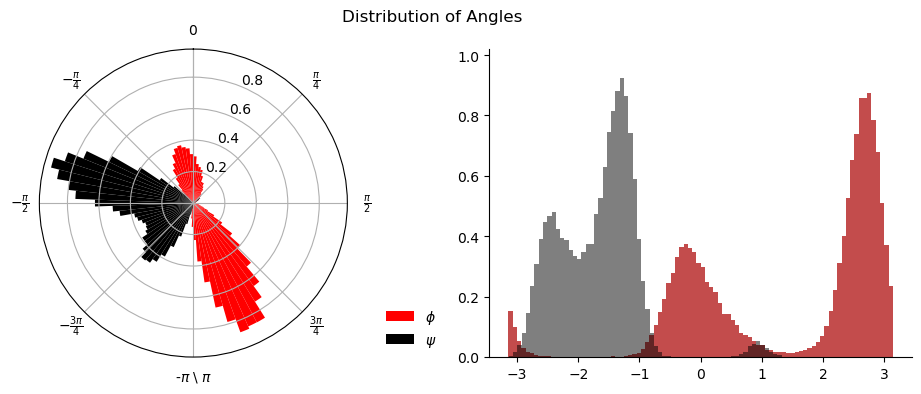

In [8]:

fig = plt.figure(figsize=(12, 4))

ax0 = fig.add_subplot(1, 2, 1, projection='polar')
ax1 = fig.add_subplot(1, 2, 2)

create_angles_hist(ax0, phi, psi)

ax1.hist(phi, bins=90, alpha=0.7, color="#AA0000", density=True)
ax1.hist(psi, bins=90, alpha=0.5, color="black", density=True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_ylim(0,1.02)


fig.suptitle("Distribution of Angles");

# Angle Animation

In [13]:
%matplotlib widget

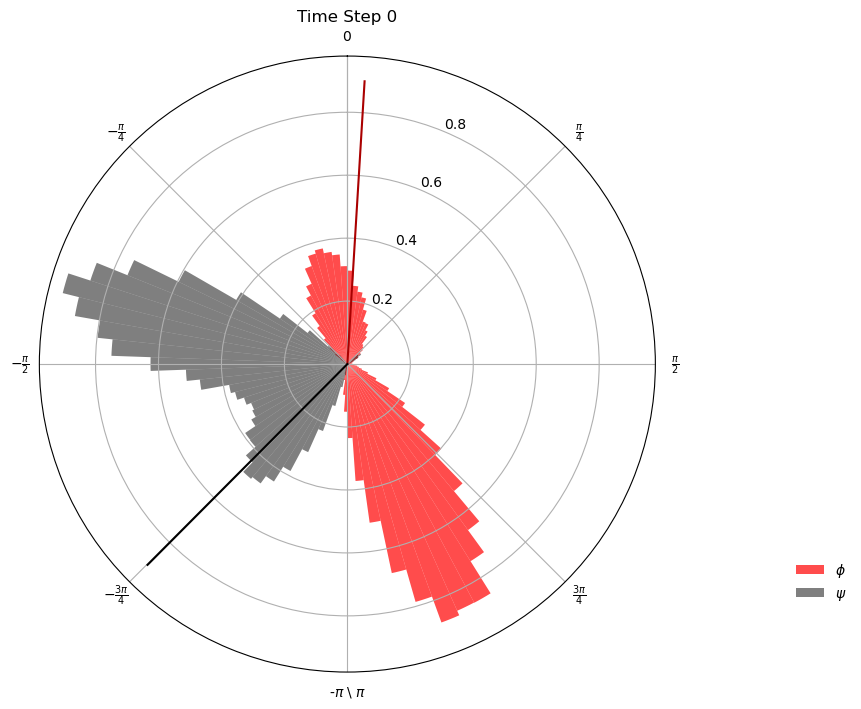

In [9]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='polar')

create_angles_hist(ax, phi, psi, alpha_phi=0.7, alpha_psi=0.5)

def init(ax):
    phi_angle, psi_angle = angles[0]
    line_phi, = ax.plot([0, phi_angle], [0, 0.9], color="#AA0000")
    line_psi, = ax.plot([0, psi_angle], [0, 0.9], color="black")
    return line_phi, line_psi

def update(i):
    phi_angle, psi_angle = phi[i], psi[i]

    line_phi.set_data([0, phi_angle], [0, 0.9])
    line_psi.set_data([0, psi_angle], [0, 0.9])

    ax.set_title(f"Time Step {i}")

    return line_phi, line_psi

line_phi, line_psi = init(ax)

ani = animation.FuncAnimation(fig, update, frames=100, blit=True, repeat=True)

plt.show()

In [6]:
plt.clf()
%matplotlib inline

# PCA of Distances

In [7]:
X = distances
n_samples = X.shape[0]
X_centered = X - np.mean(X, axis=0)
pca = PCA()
X_transformed = pca.fit_transform(X_centered)

# We center the data and compute the sample covariance matrix.
cov_matrix = np.dot(X_centered.T, X_centered) / n_samples
spectrum = [
    np.dot(eigenvector.T, np.dot(cov_matrix, eigenvector))
    for eigenvector in pca.components_
]

cumsum = np.cumsum([0] + spectrum)
cumsum /= cumsum[-1]

<Figure size 1200x400 with 0 Axes>

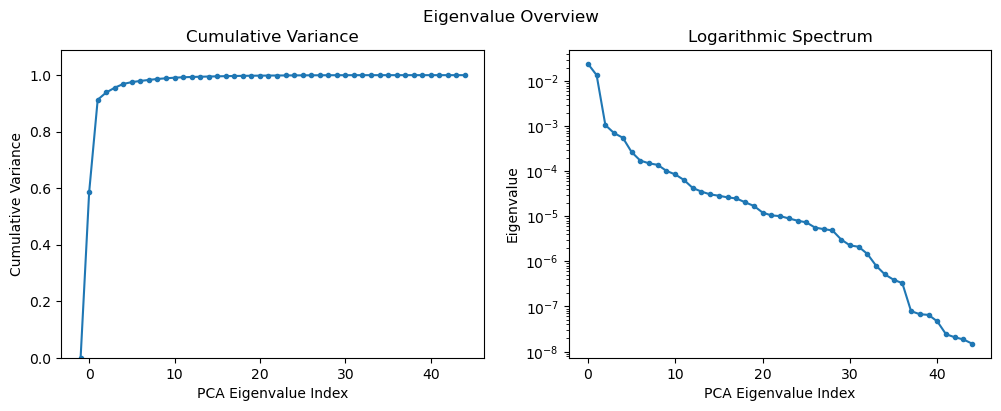

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
ax = axs[0]
ax.plot(np.arange(-1, len(cumsum) - 1), cumsum, marker='.')
ax.set_ylim(0, 1.09)
ax.set_xlabel("PCA Eigenvalue Index")
ax.set_ylabel("Cumulative Variance")
ax.set_title("Cumulative Variance")

ax = axs[1]
ax.plot(np.arange(len(spectrum)), spectrum, marker='.')
ax.set_yscale("log")
ax.set_xlabel("PCA Eigenvalue Index")
ax.set_ylabel("Eigenvalue")
ax.set_title("Logarithmic Spectrum")

fig.suptitle('Eigenvalue Overview');

In [9]:
n_clusters = 2
kmeans = KMeans(n_clusters=n_clusters, random_state=0)
phi_psi_cluster_labels = kmeans.fit_predict(angles)

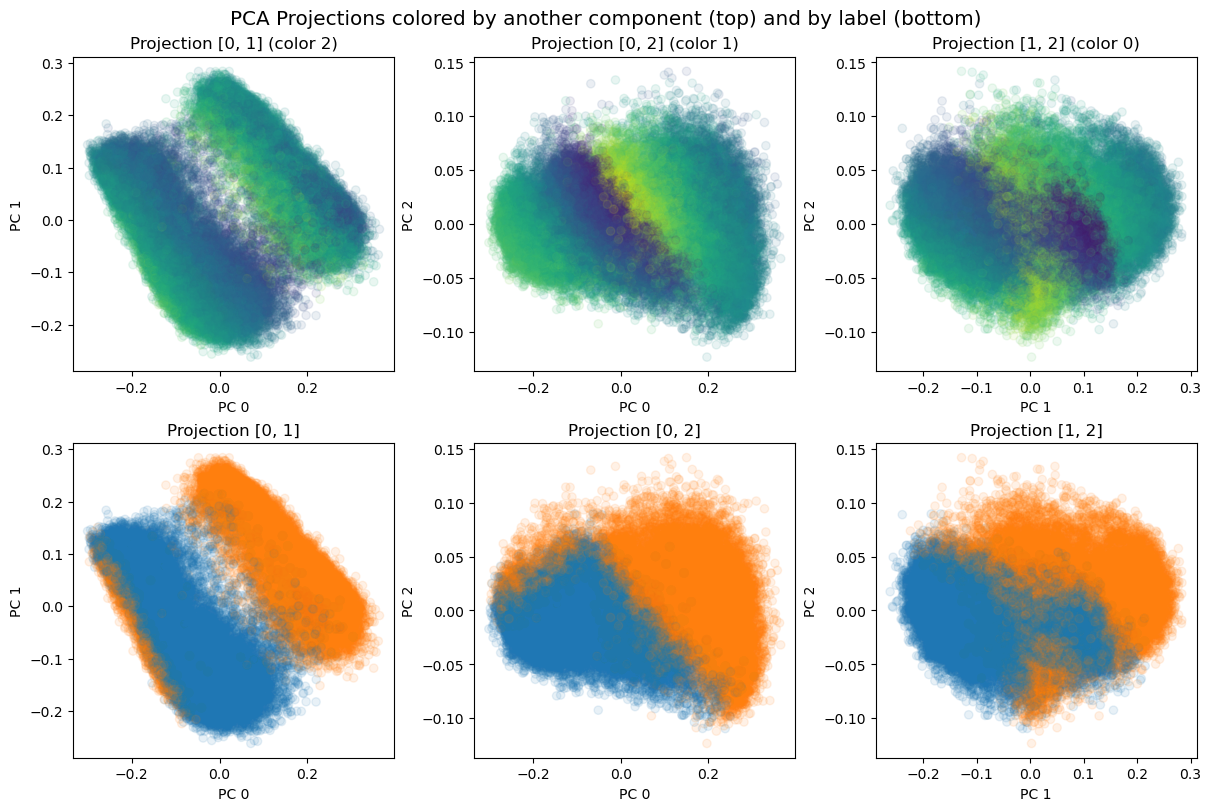

In [10]:
fig, axs = plt.subplots(2, 3, figsize=(12, 8), constrained_layout=True)

two_color_cmap = ListedColormap(["#1f77b4", "#ff7f0e"])

for ax, (i, j, k) in zip(axs[0], [(0,1, 2), (0,2, 1), (1,2, 0)]):
    ax.scatter(X_transformed[:, i], X_transformed[:, j], c=X_transformed[:, k], alpha=0.1, cmap=cm.viridis)
    ax.set_xlabel(f'PC {i}')
    ax.set_ylabel(f'PC {j}')
    ax.set_title(f'Projection [{i}, {j}] (color {k})')

for ax, (i, j, k) in zip(axs[1], [(0,1, 2), (0,2, 1), (1,2, 0)]):
    ax.scatter(X_transformed[:, i], X_transformed[:, j], c=phi_psi_cluster_labels, cmap=two_color_cmap, alpha=0.1);
    ax.set_xlabel(f'PC {i}')
    ax.set_ylabel(f'PC {j}')
    ax.set_title(f'Projection [{i}, {j}]')
    
fig.suptitle("PCA Projections colored by another component (top) and by label (bottom)", size="x-large");

In [181]:
%matplotlib widget

In [5]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_transformed[:, 0], X_transformed[:, 1], X_transformed[:, 2], c=X_transformed[:, 3], alpha=0.1, cmap=cm.magma)
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')
ax.set_title('3D PCA Projection')
plt.show()

In [6]:
%matplotlib inline

# Length Distribution

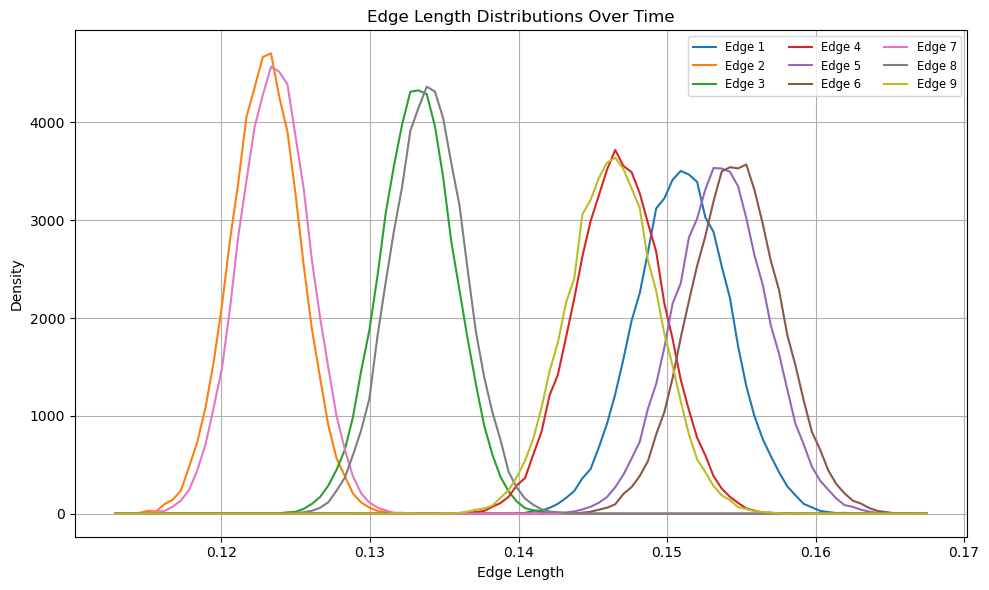

In [11]:
# Extract coordinates for both ends of each edge
start = positions[:, edges[:, 0], :]  # shape (50000, 9, 3)
end = positions[:, edges[:, 1], :]  # shape (50000, 9, 3)

lengths = np.linalg.norm(start - end, axis=2)

num_bins = 100
all_data = lengths.ravel()
bin_edges = np.linspace(all_data.min(), all_data.max(), num_bins + 1)

plt.figure(figsize=(10, 6))

for edge_idx in range(lengths.shape[1]):
    hist, _ = np.histogram(lengths[:, edge_idx], bins=bin_edges)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    plt.plot(bin_centers, hist, label=f'Edge {edge_idx + 1}')

plt.xlabel('Edge Length')
plt.ylabel('Density')
plt.title('Edge Length Distributions Over Time')
plt.legend(ncol=3, fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()